In [133]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import string
import pandas as pd

In [134]:
df = pd.read_csv("scraped_datasets/fb_comments/SAMPLE_ALL_COMMENTS_PREPROCESSED_DATASET.99.csv")
df["Final Annotation"] = pd.to_numeric(df["Final Annotation"], errors="coerce")
df = df[df["Final Annotation"].isin([0, 1, 2])].dropna(subset=["Final Annotation"])
df["label"] = df["Final Annotation"].astype(int)

# List of spammy phrases or keywords to exclude
spam_keywords = [
    "magjistar", "shtrigë", "falje", "facebook.com", "contact", "magji", "Dr Okoro", "shoq", "faqen"
]

def is_spam(comment):
    lower_comment = str(comment).lower()
    return any(keyword in lower_comment for keyword in spam_keywords)


df_cleaned = df[~df["Comment"].apply(is_spam)]

/var/folders/5s/qkz8xslx1bb8qjvtc601pfn80000gp/T/ipykernel_21524/3310575924.py:1: DtypeWarning: Columns (0,1,2,3,4,5,6,7,9,10,11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("scraped_datasets/fb_comments/SAMPLE_ALL_COMMENTS_PREPROCESSED_DATASET.99.csv")


/var/folders/5s/qkz8xslx1bb8qjvtc601pfn80000gp/T/ipykernel_21524/2841004799.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="label", data=df_cleaned, palette="pastel")


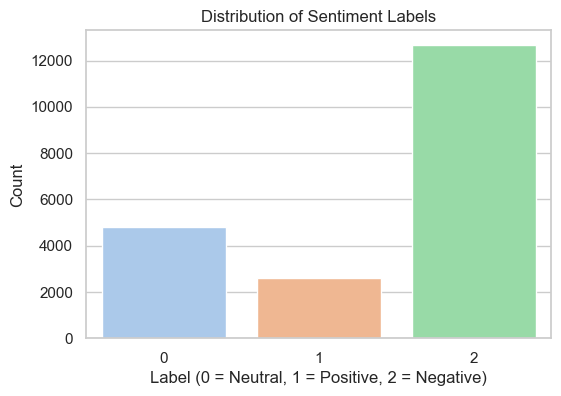

In [135]:
plt.figure(figsize=(6,4))
sns.countplot(x="label", data=df_cleaned, palette="pastel")
plt.title("Distribution of Sentiment Labels")
plt.xlabel("Label (0 = Neutral, 1 = Positive, 2 = Negative)")
plt.ylabel("Count")
plt.show()


/var/folders/5s/qkz8xslx1bb8qjvtc601pfn80000gp/T/ipykernel_21524/4193677381.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned["comment_length"] = df_cleaned["Comment"].apply(lambda x: len(str(x).split()))


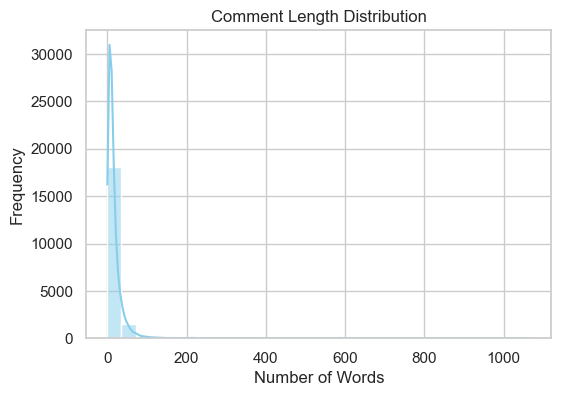

In [136]:
df_cleaned["comment_length"] = df_cleaned["Comment"].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(6,4))
sns.histplot(df_cleaned["comment_length"], bins=30, kde=True, color="skyblue")
plt.title("Comment Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()


In [137]:
# Original Albanian stopwords
raw_albanian_stopwords = [
    "dhe", "në", "për", "me", "që", "është", "e", "të", "nga", "si", "një", "po",
    "nuk", "ka", "do", "jam", "ke", "ai", "ajo", "ne", "ju", "kjo", "këtë", "është",
    "çfarë", "kush", "pse", "kur", "ku", "janë", "ishte", "jemi", "ata", "ato",
    "ndaj", "sepse", "apo", "nëse", "mbi", "mos", "pa", "vetëm", "ndër", "kështu", "i",
    "edhe", "u", "shumë", "a", "ti", "im", "por", "që", "kam", "pas", "sa", "kan", "se",
    "ta", "ky", "jo", "po", "ma", "une", "deri", "o", "ai", "as", "tij", "keni", "ate", "na",
    "ja", "je", "jeni", "kta", "shum", "veq", "jan", "more", "duhet", "ba", "bo", "prej", "krejt",
    "ket", "tu", "vet", "asht", "ky", "ska", "qka", "ky", "qysh", "ty", "mi", "juve", "ki", "ke", 
    "kemi", "kem", "ni", "nje", "tash", "bre", "esht", "osht", "qen"
]

# Normalize: replace ë → e and optionally ç → c
albanian_stopwords = set(
    word.replace("ë", "e").replace("ç", "c") for word in raw_albanian_stopwords
)
stop_words = albanian_stopwords

sns.set(style="whitegrid")



/var/folders/5s/qkz8xslx1bb8qjvtc601pfn80000gp/T/ipykernel_21524/3735699283.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), palette="mako")


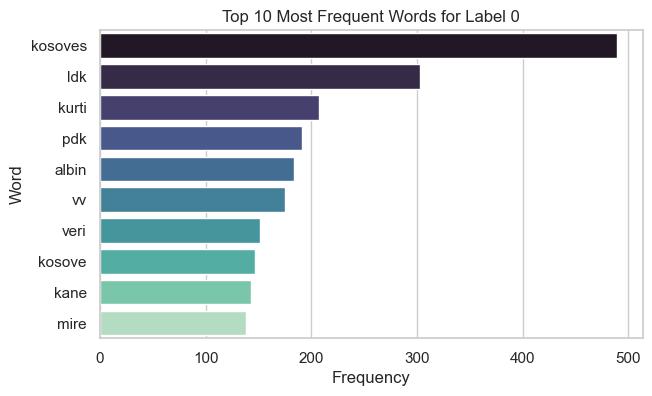

/var/folders/5s/qkz8xslx1bb8qjvtc601pfn80000gp/T/ipykernel_21524/3735699283.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), palette="mako")


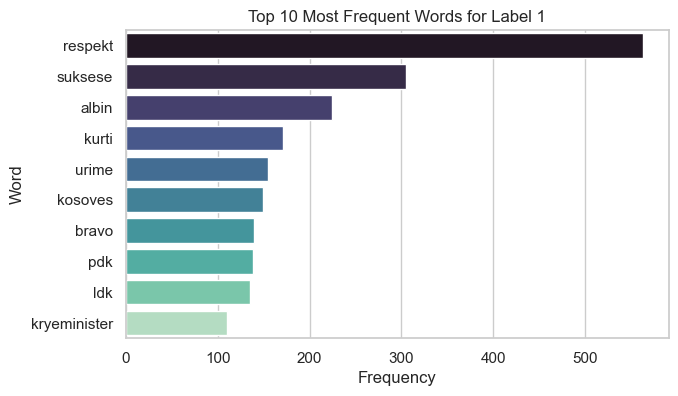

/var/folders/5s/qkz8xslx1bb8qjvtc601pfn80000gp/T/ipykernel_21524/3735699283.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), palette="mako")


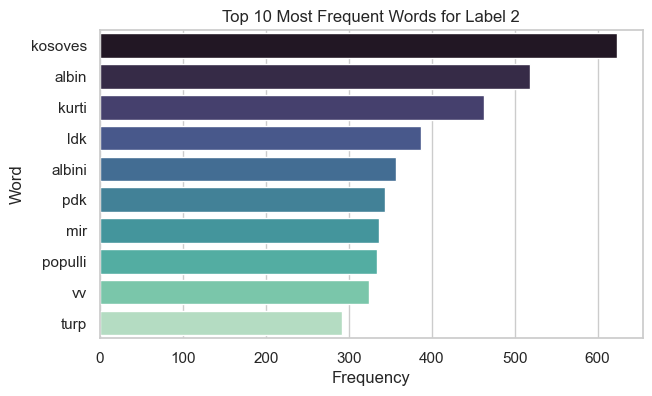

In [138]:
from collections import Counter

def preprocess_tokens(text):
    # Normalize and remove stopwords/punctuation
    words = str(text).lower().translate(str.maketrans('', '', string.punctuation)).split()
    words = [w.replace("ë", "e").replace("ç", "c") for w in words]  # normalize
    return [w for w in words if w not in stop_words]

# Show top 10 words for each label
for label in sorted(df_cleaned["label"].unique()):
    all_words = df_cleaned[df_cleaned["label"] == label]["Comment"].dropna().apply(preprocess_tokens)
    flat_words = [word for sublist in all_words for word in sublist]  # flatten
    counter = Counter(flat_words).most_common(10)

    # Plot
    words, counts = zip(*counter)
    plt.figure(figsize=(7,4))
    sns.barplot(x=list(counts), y=list(words), palette="mako")
    plt.title(f"Top 10 Most Frequent Words for Label {label}")
    plt.xlabel("Frequency")
    plt.ylabel("Word")
    plt.show()



/var/folders/5s/qkz8xslx1bb8qjvtc601pfn80000gp/T/ipykernel_21524/2986311553.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=values, y=labels, palette="coolwarm")


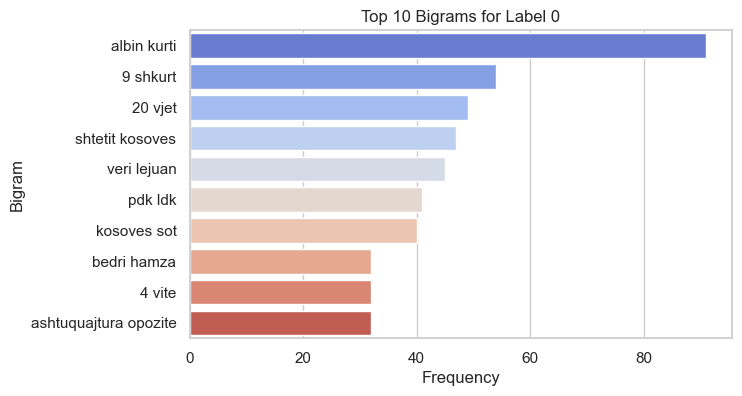

/var/folders/5s/qkz8xslx1bb8qjvtc601pfn80000gp/T/ipykernel_21524/2986311553.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=values, y=labels, palette="coolwarm")
/Users/melisa-uni/Desktop/KosovoElectionSentiment2025/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10084 (\N{HEAVY BLACK HEART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/melisa-uni/Desktop/KosovoElectionSentiment2025/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


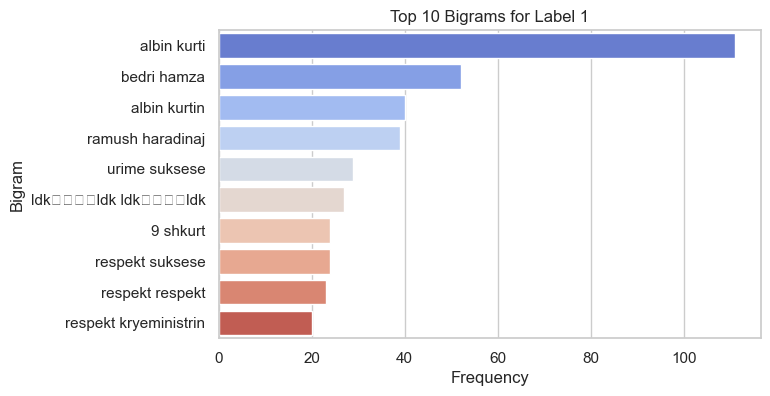

/var/folders/5s/qkz8xslx1bb8qjvtc601pfn80000gp/T/ipykernel_21524/2986311553.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=values, y=labels, palette="coolwarm")


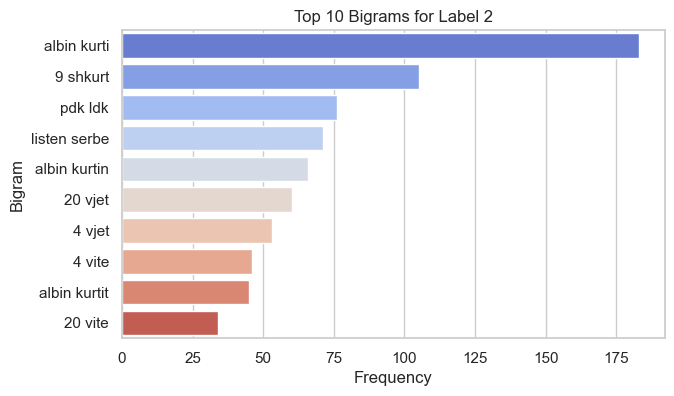

In [139]:
from nltk import bigrams
from collections import Counter

def get_top_bigrams(label, n=10):
    comments = df_cleaned[df_cleaned["label"] == label]["Comment"].dropna().apply(preprocess_tokens)
    all_bigrams = [pair for tokens in comments for pair in bigrams(tokens)]
    return Counter(all_bigrams).most_common(n)

# Plot top bigrams
for label in sorted(df_cleaned["label"].unique()):
    top_bgs = get_top_bigrams(label)
    labels = [f"{a} {b}" for (a, b), _ in top_bgs]
    values = [count for _, count in top_bgs]

    plt.figure(figsize=(7,4))
    sns.barplot(x=values, y=labels, palette="coolwarm")
    plt.title(f"Top 10 Bigrams for Label {label}")
    plt.xlabel("Frequency")
    plt.ylabel("Bigram")
    plt.show()


In [141]:
# Ensure timestamp is datetime
df_cleaned["Comment Timestamp"] = pd.to_datetime(df_cleaned["Comment Timestamp"], errors="coerce")
df_cleaned = df_cleaned.dropna(subset=["Comment Timestamp"])

# Set index to enable resampling
df_cleaned.set_index("Comment Timestamp", inplace=True)


/var/folders/5s/qkz8xslx1bb8qjvtc601pfn80000gp/T/ipykernel_21524/1765376181.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned["Comment Timestamp"] = pd.to_datetime(df_cleaned["Comment Timestamp"], errors="coerce")


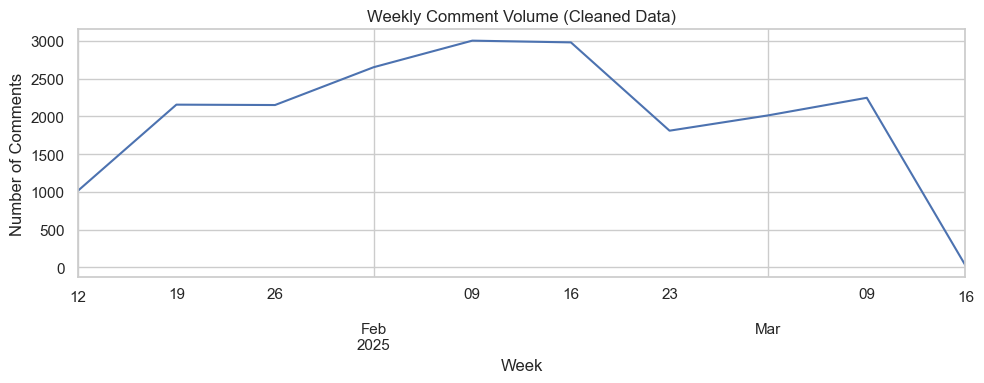

In [142]:
weekly_counts = df_cleaned.resample("W")["Comment"].count()

plt.figure(figsize=(10,4))
weekly_counts.plot()
plt.title("Weekly Comment Volume (Cleaned Data)")
plt.xlabel("Week")
plt.ylabel("Number of Comments")
plt.grid(True)
plt.tight_layout()
plt.show()


<Figure size 1000x500 with 0 Axes>

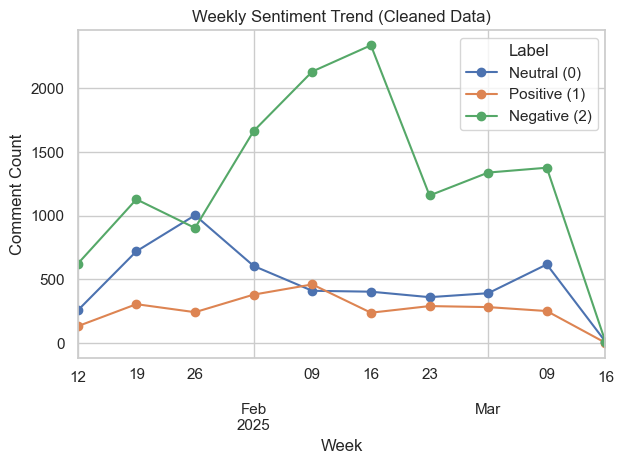

In [143]:
weekly_sentiment = df_cleaned.resample("W")["label"].value_counts().unstack(fill_value=0)

plt.figure(figsize=(10,5))
weekly_sentiment.plot(kind="line", marker="o")
plt.title("Weekly Sentiment Trend (Cleaned Data)")
plt.xlabel("Week")
plt.ylabel("Comment Count")
plt.legend(title="Label", labels=["Neutral (0)", "Positive (1)", "Negative (2)"])
plt.grid(True)
plt.tight_layout()
plt.show()


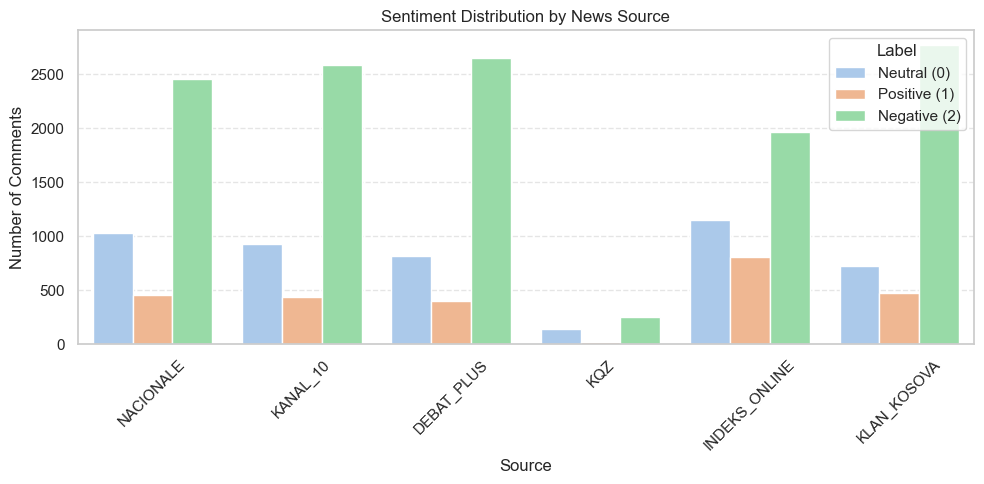

In [144]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.countplot(data=df_cleaned, x="Source", hue="label", palette="pastel")

plt.title("Sentiment Distribution by News Source")
plt.xlabel("Source")
plt.ylabel("Number of Comments")
plt.legend(title="Label", labels=["Neutral (0)", "Positive (1)", "Negative (2)"])
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()



In [145]:
df_cleaned.reset_index(inplace=True)

/var/folders/5s/qkz8xslx1bb8qjvtc601pfn80000gp/T/ipykernel_21524/2816884956.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned["Comment Timestamp"] = pd.to_datetime(df_cleaned["Comment Timestamp"], errors="coerce")
/var/folders/5s/qkz8xslx1bb8qjvtc601pfn80000gp/T/ipykernel_21524/2816884956.py:33: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
/Users/melisa-uni/Desktop/KosovoElectionSentiment2025/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/melisa-uni/Desktop/KosovoElectionSentiment2025/.venv/lib/python3.13/site-packages/IPy

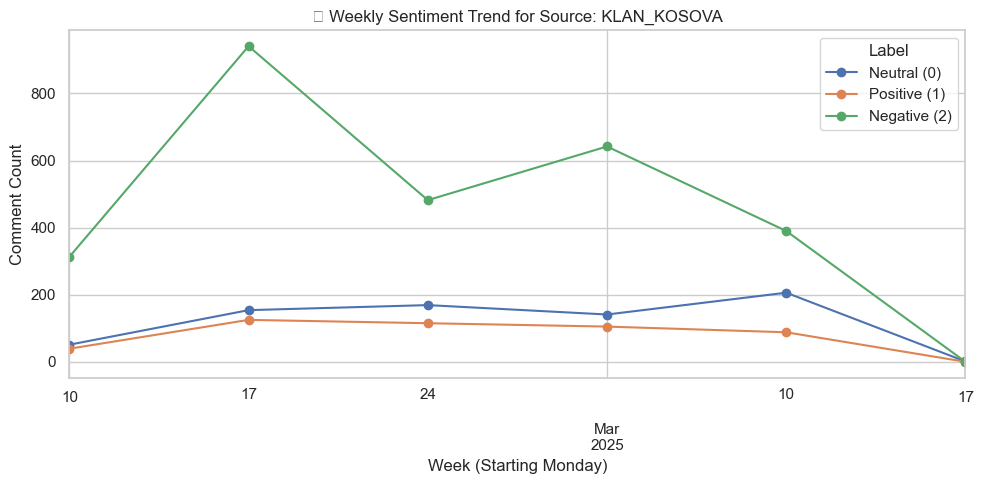

/var/folders/5s/qkz8xslx1bb8qjvtc601pfn80000gp/T/ipykernel_21524/2816884956.py:33: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
/Users/melisa-uni/Desktop/KosovoElectionSentiment2025/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/melisa-uni/Desktop/KosovoElectionSentiment2025/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


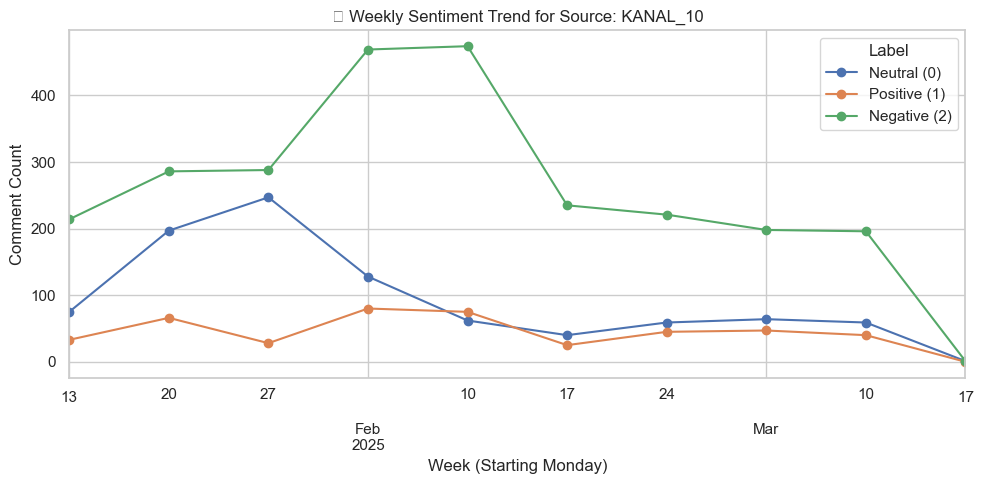

/var/folders/5s/qkz8xslx1bb8qjvtc601pfn80000gp/T/ipykernel_21524/2816884956.py:33: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
/Users/melisa-uni/Desktop/KosovoElectionSentiment2025/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/melisa-uni/Desktop/KosovoElectionSentiment2025/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


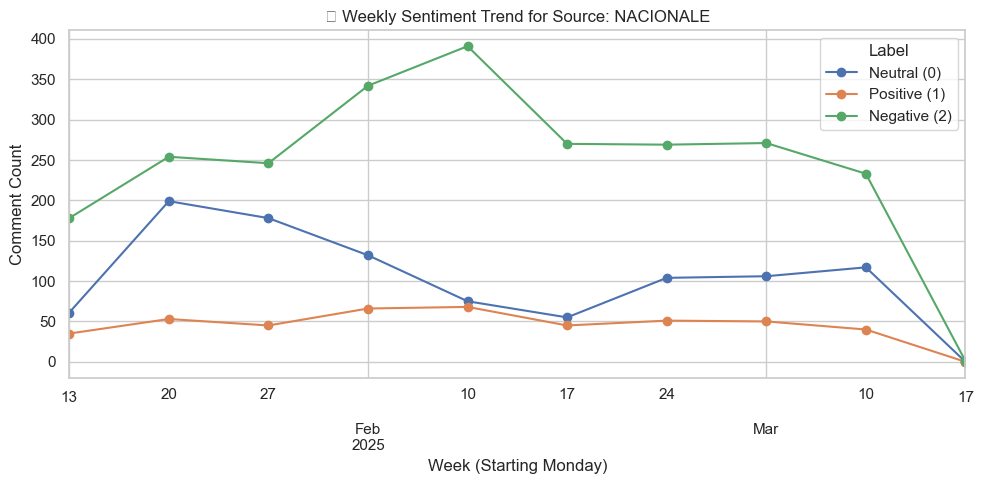

In [146]:
# Ensure datetime is parsed and set as index
df_cleaned["Comment Timestamp"] = pd.to_datetime(df_cleaned["Comment Timestamp"], errors="coerce")
df_cleaned = df_cleaned.dropna(subset=["Comment Timestamp"])
df_cleaned = df_cleaned.set_index("Comment Timestamp")

# Optional: focus on top 3 most frequent sources
top_sources = df_cleaned["Source"].value_counts().head(3).index
df_top_sources = df_cleaned[df_cleaned["Source"].isin(top_sources)]

# Group by week + source + label
grouped = (
    df_top_sources
    .groupby([pd.Grouper(freq="W-MON"), "Source", "label"])
    .size()
    .reset_index(name="count")
)

# Plot weekly sentiment per source
import seaborn as sns
import matplotlib.pyplot as plt

for source in top_sources:
    src_data = grouped[grouped["Source"] == source]
    pivoted = src_data.pivot(index="Comment Timestamp", columns="label", values="count").fillna(0)

    plt.figure(figsize=(10, 5))
    pivoted.plot(ax=plt.gca(), marker="o")
    plt.title(f"📈 Weekly Sentiment Trend for Source: {source}")
    plt.xlabel("Week (Starting Monday)")
    plt.ylabel("Comment Count")
    plt.legend(title="Label", labels=["Neutral (0)", "Positive (1)", "Negative (2)"])
    plt.grid(True)
    plt.tight_layout()
    plt.show()



/var/folders/5s/qkz8xslx1bb8qjvtc601pfn80000gp/T/ipykernel_21524/2265727879.py:41: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) Arial.
  plt.tight_layout()


<Figure size 1000x600 with 0 Axes>

/Users/melisa-uni/Desktop/KosovoElectionSentiment2025/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


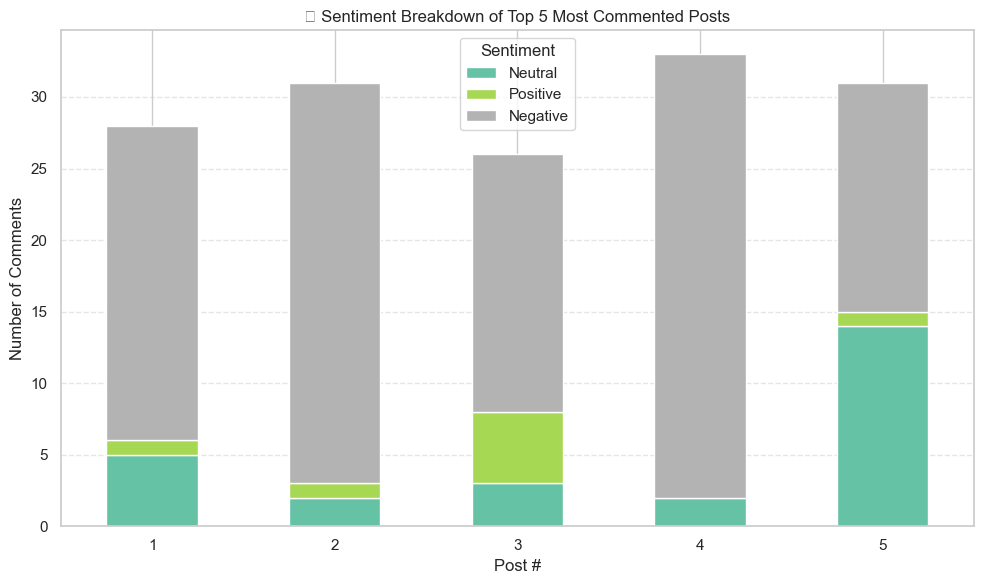


📌 Post Reference Table
1. procesi i numerimit te votave ka filluar ne qendrat komunale te numerimit ne kater komunat, prishtine, obiliq, lipjan dhe partesh, nderkaq ne qendrat e komunave te tjera, numerimi planifikohet te filloje pasi te behen te gjitha pergatitjet e duhura teknike dhe administrative.

ne qkn, pervec procesit te numerimit te votave te kandidateve per deputete, do te behet verifikimi i votave te subjekteve politike nga formularet te cilet jane plotesuar ne vendvotime pas numerimit te votave per subjektet politike.
2. pengimi i numerimit, kurteshi i vv-se trazon komisioneret
3. sipas te dhenave te pranuara nga qendrat komunale te numerimit (sipas tabeles) ne te cilat eshte duke vazhduar procesi i numerimit te votave te kandidateve apo ka perfunduar, deri me 14 shkurt 2025 jane numeruar 876 vendvotime nga 2,533. 

procesi i numerimit te votave ka perfunduar ne 9 qendrat komunale te numerimit (qkn) ne komunat: novoberde, obiliq, shterpce, junik, hani i elezit, partesh, ra

In [148]:
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Ensure valid sentiment labels
df_cleaned["label"] = pd.to_numeric(df_cleaned["label"], errors="coerce")
df_cleaned = df_cleaned[df_cleaned["label"].isin([0, 1, 2])]

# Step 2: Get top 5 Post URLs by comment count
top_posts = df_cleaned["Post URL"].value_counts().head(5)
top_urls = top_posts.index.tolist()

# Step 3: Get related comments
top_comments = df_cleaned[df_cleaned["Post URL"].isin(top_urls)]

# Step 4: Sentiment count per post
sentiment_summary = (
    top_comments.groupby("Post URL")["label"]
    .value_counts()
    .unstack(fill_value=0)
    .rename(columns={0: "Neutral", 1: "Positive", 2: "Negative"})
)

# Step 5: Map post URLs to short titles
url_to_title = (
    all_posts.set_index("url")["text"]
    .apply(lambda x: x if isinstance(x, str) else "No Title")
    .to_dict()
)

# Step 6: Assign numeric labels (1–5) for plot
numeric_labels = [f"{i+1}" for i in range(len(sentiment_summary))]
sentiment_summary.index = numeric_labels

# Step 7: Plot
plt.figure(figsize=(10, 6))
sentiment_summary.plot(kind="bar", stacked=True, colormap="Set2", figsize=(10, 6))
plt.title("Sentiment Breakdown of Top 5 Most Commented Posts")
plt.xlabel("Post #")
plt.ylabel("Number of Comments")
plt.xticks(rotation=0)
plt.tight_layout()
plt.legend(title="Sentiment")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

# Step 8: Display mapping table
print("\n📌 Post Reference Table")
for i, url in enumerate(top_urls):
    print(f"{i+1}. {url_to_title.get(url, 'Unknown Title')}")



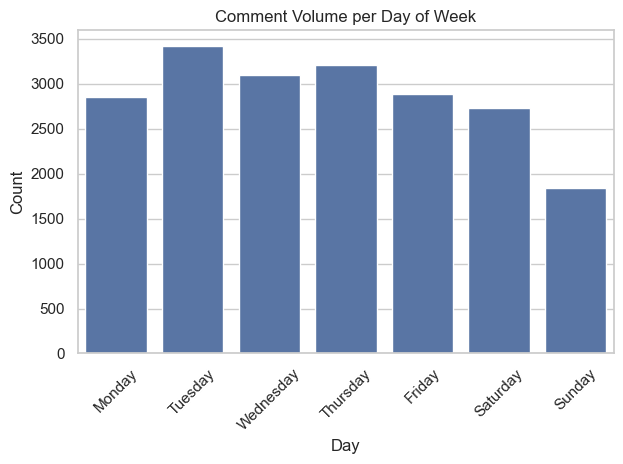

In [149]:
# Daily comments
df_cleaned["hour"] = df_cleaned.index.hour
df_cleaned["weekday"] = df_cleaned.index.day_name()

sns.countplot(data=df_cleaned, x="weekday", order=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])
plt.title("Comment Volume per Day of Week")
plt.xlabel("Day")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


/var/folders/5s/qkz8xslx1bb8qjvtc601pfn80000gp/T/ipykernel_21524/2918727958.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label", y="comment_length", data=df_cleaned, palette="Set2")


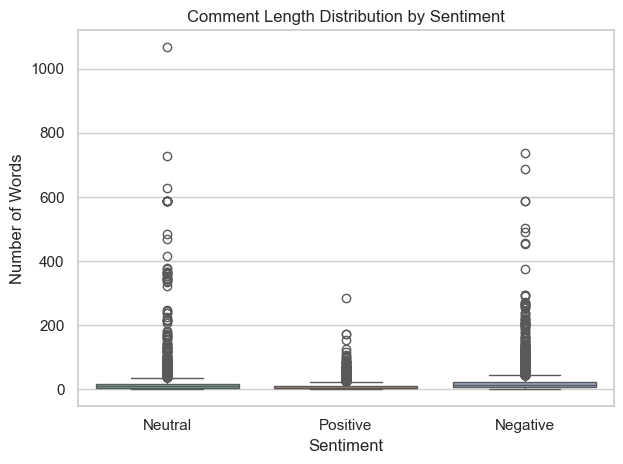

In [151]:
df_cleaned["comment_length"] = df_cleaned["Comment"].apply(lambda x: len(str(x).split()))
sns.boxplot(x="label", y="comment_length", data=df_cleaned, palette="Set2")
plt.title("Comment Length Distribution by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Words")
plt.xticks([0,1,2], ["Neutral", "Positive", "Negative"])
plt.tight_layout()
plt.show()
